# Module 10 · Xác suất, biến ngẫu nhiên và hàm đặc trưng

**Nguồn sách:** Bracewell, chương 16, tr. 427–445; Barkat, chương 1, tr. 1–73

Notebook đi kèm bài giảng cùng số module. Chạy lần lượt từng cell; sau mỗi cell có phần **📤 Đầu ra thật** giải thích con số.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """Phổ biên độ một phía: sóng hình sin biên độ A cho vạch A, thành phần một chiều cho đúng giá trị của nó"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """In một kết quả có tên, bỏ các số 0 thừa ở cuối (trang web đọc các dòng bắt đầu bằng ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Tập hợp, đếm và Bayes
🎯 **Phương pháp này trả lời câu hỏi gì?** Các xác suất trong ví dụ của Barkat (xúc xắc, bình bóng, kênh nhị phân) có đúng khi tính bằng phân số chính xác và bằng mô phỏng độc lập?

In [2]:
from fractions import Fraction as Fr
from itertools import product, permutations
from math import comb, factorial, perm
from scipy import integrate, special, stats, optimize
trap = getattr(np, "trapezoid", None) or np.trapz
rg = np.random.default_rng(10)
S = list(product(range(1, 7), repeat=2))
A = [s for s in S if sum(s) == 7]; B = [s for s in S if (s[0] + s[1]) % 2 == 1]
pa = Fr(len(A), 36); pb = Fr(len(B), 36); pab = Fr(len([s for s in A if s in B]), 36)
assert pa == Fr(1, 6) and pb == Fr(1, 2) and pab == pa
pmf2 = np.convolve(np.ones(6)/6, np.ones(6)/6)                     # hai xúc xắc: tích chập
assert abs(pmf2[5] - 1/6) < 1e-15 and abs(pmf2.sum() - 1) < 1e-15
report("d_pa", float(pa), ".4f"); report("d_pb", float(pb), ".4f"); report("d_pab", float(pab), ".4f"); report("d_pna", float(1 - pa), ".4f")
report("d_pun", float(pa + pb - pab), ".4f"); report("sub_n", 2**6, "d")
d1 = rg.integers(1, 7, 200000); d2 = rg.integers(1, 7, 200000)
freq = np.mean(d1 + d2 == 7)
assert abs(freq - 1/6) < 0.004
report("d_freq", freq, ".3f")

# đếm
assert 26**5 == 11881376 and perm(26, 5) == 26*25*24*23*22 == 7893600
assert comb(14, 6) == factorial(14)//(factorial(8)*factorial(6)) == 3003
report("cnt_rep", 26**5, "d"); report("cnt_perm", perm(26, 5), "d"); report("cnt_c146", comb(14, 6), "d")

# cây, ví dụ 1.3
p2w = Fr(1, 2)*(Fr(2, 7)*Fr(1, 6)) + Fr(1, 2)*(Fr(2, 5)*Fr(1, 4))
N = 400000
which = rg.integers(0, 2, N)
def two_white(u):
    balls = [1, 1, 0, 0, 0, 0, 0] if u == 0 else [1, 1, 0, 0, 0]
    return None
cnt = 0
for u, nb_w, nb_tot in ((0, 2, 7), (1, 2, 5)):
    n_u = int(np.sum(which == u))
    arr = np.array([1]*nb_w + [0]*(nb_tot - nb_w))
    draws = np.argsort(rg.random((n_u, nb_tot)), axis=1)[:, :2]
    cnt += int(np.sum(arr[draws].sum(axis=1) == 2))
assert abs(cnt/N - float(p2w)) < 0.003
report("urn_tree", float(p2w), ".4f")
# ví dụ 1.4
multi = Fr(comb(5, 2)*comb(3, 1)*comb(4, 2)*comb(2, 1), comb(14, 6))
lab = np.array([0]*5 + [1]*3 + [2]*4 + [3]*2)
Nm = 200000
sel = np.argsort(rg.random((Nm, 14)), axis=1)[:, :6]
counts = np.stack([(lab[sel] == c).sum(axis=1) for c in range(4)], axis=1)
mc = np.mean((counts == [2, 1, 2, 1]).all(axis=1))
assert abs(mc - float(multi)) < 0.003 and multi == Fr(360, 3003)
report("urn_multi", float(multi), ".4f")

# ví dụ 1.7: hai cách: công thức và liệt kê
colors = ["W"]*7 + ["R"]*3 + ["G"]*6
rep = sum(1 for t in product(range(16), repeat=3) if (colors[t[0]], colors[t[1]], colors[t[2]]) == ("R", "W", "G"))
norep = sum(1 for t in permutations(range(16), 3) if (colors[t[0]], colors[t[1]], colors[t[2]]) == ("R", "W", "G"))
assert Fr(rep, 16**3) == Fr(3, 16)*Fr(7, 16)*Fr(6, 16) and Fr(norep, 16*15*14) == Fr(3, 16)*Fr(7, 15)*Fr(6, 14)
report("rw_repl", rep/16**3, ".4f"); report("rw_norepl", norep/(16*15*14), ".4f")

# kênh nhị phân, ví dụ 1.6
p0, p1_, gar = Fr(6, 10), Fr(4, 10), Fr(2, 10)
pr0 = (1 - gar)*p0 + gar*p1_
post = (1 - gar)*p0/pr0
sent = rg.random(500000) < 0.6                                  # gửi 0 với 0.6
recv0 = np.where(rg.random(500000) < 0.2, ~sent, sent)
assert abs(np.mean(recv0) - float(pr0)) < 0.004 and abs(np.mean(sent[recv0]) - float(post)) < 0.004
report("ch_r0", float(pr0), ".4f"); report("ch_post", float(post), ".4f")
# ba bình
tab = {"A": (5, 6, 2), "B": (3, 3, 4), "C": (6, 2, 1)}
pw = sum(Fr(1, 3)*Fr(v[2], sum(v)) for v in tab.values())
pB = Fr(1, 3)*Fr(4, 10)/pw
urn = rg.integers(0, 3, 400000); names = ["A", "B", "C"]
pw_mc = np.mean([0]*0 or [1]) if False else None
wprob = np.array([Fr(tab[n][2], sum(tab[n])) for n in names], dtype=float)
white = rg.random(400000) < wprob[urn]
assert abs(np.mean(white) - float(pw)) < 0.003 and abs(np.mean(urn[white] == 1) - float(pB)) < 0.005
report("urn_pw", float(pw), ".4f"); report("urn_pb", float(pB), ".4f")

# độc lập vs loại trừ
Aa = [s for s in S if sum(s) == 7]; Bb = [s for s in S if s[0] == 1]; Cc = [s for s in S if sum(s) == 2]; Dd = [s for s in S if sum(s) == 12]
pAB = Fr(len([s for s in Aa if s in Bb]), 36)
assert pAB == Fr(len(Aa), 36)*Fr(len(Bb), 36)
assert Fr(len([s for s in Cc if s in Dd]), 36) == 0 and Fr(len(Cc), 36)*Fr(len(Dd), 36) == Fr(1, 1296)
report("ind_ab", float(pAB), ".4f"); report("ind_cd", 0.0, ".4f"); report("ind_cd_prod", 1/1296, ".5f")

▸ d_pa = 0.1667
▸ d_pb = 0.5
▸ d_pab = 0.1667
▸ d_pna = 0.8333
▸ d_pun = 0.5
▸ sub_n = 64
▸ d_freq = 0.166
▸ cnt_rep = 11881376
▸ cnt_perm = 7893600
▸ cnt_c146 = 3003
▸ urn_tree = 0.0738
▸ urn_multi = 0.1199
▸ rw_repl = 0.0308
▸ rw_norepl = 0.0375
▸ ch_r0 = 0.56
▸ ch_post = 0.8571
▸ urn_pw = 0.2217
▸ urn_pb = 0.6015
▸ ind_ab = 0.0278
▸ ind_cd = 0
▸ ind_cd_prod = 0.00077


#### 📤 Đầu ra thật
Hai xúc xắc: $P(A)$ = 0.1667, $P(B)$ = 0.5, $P(A\cup B)$ = 0.5; tần suất 0.166. Đếm: 11881376, 7893600, $\binom{14}6$ = 3003. Bình: 0.0738, 0.1199, 0.0308 và 0.0375. Kênh: 0.56 và 0.8571; ba bình 0.2217 và 0.6015. Độc lập: 0.0278; loại trừ: 0 và 0.00077.

## 2. Biến ngẫu nhiên và mômen
🎯 **Phương pháp này trả lời câu hỏi gì?** Xác suất, kỳ vọng, phương sai của biến rời rạc, liên tục và hỗn hợp có khớp giữa tích phân, phân số chính xác và mô phỏng?

In [3]:
# hai xúc xắc
xv = np.arange(2, 13)
assert abs(pmf2[2:5].sum() - 1/3) < 1e-15 and abs(pmf2[3:].sum() - 5/6) < 1e-15     # P(4≤X≤6) = indices 2..4; P(X≥5) = indices 3..
dice_ge5 = 1 - pmf2[:3].sum()
assert abs(dice_ge5 - 5/6) < 1e-15
mean2 = np.sum(xv*pmf2); var2 = np.sum(xv**2*pmf2) - mean2**2
assert abs(mean2 - 7) < 1e-12 and abs(var2 - 35/6) < 1e-12
assert abs(var2 - 2*(35/12)) < 1e-12
report("dice_46", pmf2[2:5].sum(), ".4f"); report("dice_ge5", 5/6, ".4f"); report("dice_e", mean2, ".4f"); report("dice_var", var2, ".4f")
report("die_e", np.mean(np.arange(1, 7)), ".1f")

# ví dụ 1.10
cc = 1/integrate.quad(lambda x: x, 0, 3)[0]
assert abs(cc - 2/9) < 1e-12
p12 = integrate.quad(lambda x: cc*x, 1, 2)[0]
assert abs(p12 - 1/3) < 1e-12 and abs(integrate.quad(lambda x: cc*x, 0, 2)[0] - 4/9) < 1e-12
report("pdf_c", cc, ".4f"); report("pdf_p12", p12, ".4f"); report("pdf_F2", 4/9, ".4f")

# ví dụ 1.12, 1.13
f12 = lambda x: 0.25 if abs(x) < 1 else (0.125 if abs(x) < 3 else 0.0)
tot = integrate.quad(f12, -3, 3, points=[-1, 1])[0]
E12 = integrate.quad(lambda x: x*f12(x), -3, 3, points=[-1, 1])[0]
V12 = integrate.quad(lambda x: x*x*f12(x), -3, 3, points=[-1, 1])[0]
assert abs(tot - 1) < 1e-12 and abs(E12) < 1e-12 and abs(V12 - 7/3) < 1e-10
# mô phỏng: chọn miền theo xác suất
u = rg.random(400000)
xs = np.where(u < 0.5, rg.uniform(-1, 1, 400000), np.where(rg.random(400000) < 0.5, rg.uniform(1, 3, 400000), rg.uniform(-3, -1, 400000)))
assert abs(np.mean(xs**2) - 7/3) < 0.02
report("ex12_e", 0.0, ".4f"); report("ex12_var", V12, ".4f")

# chỉnh lưu nửa sóng, X chuẩn
phi = lambda x: np.exp(-x*x/2)/np.sqrt(2*np.pi)
EY = integrate.quad(lambda x: x*phi(x), 0, np.inf)[0]; EY2 = integrate.quad(lambda x: x*x*phi(x), 0, np.inf)[0]
Xn = rg.standard_normal(1000000); Yr = np.maximum(Xn, 0)
assert abs(EY - 1/np.sqrt(2*np.pi)) < 1e-10 and abs(np.mean(Yr) - EY) < 3e-3 and abs(np.var(Yr) - (0.5 - 1/(2*np.pi))) < 3e-3
assert abs(np.mean(Yr == 0) - 0.5) < 2e-3
report("rect_p0", 0.5, ".4f"); report("rect_e", EY, ".4f"); report("rect_var", EY2 - EY**2, ".4f")

▸ dice_46 = 0.3333
▸ dice_ge5 = 0.8333
▸ dice_e = 7
▸ dice_var = 5.8333
▸ die_e = 3.5
▸ pdf_c = 0.2222
▸ pdf_p12 = 0.3333
▸ pdf_F2 = 0.4444
▸ ex12_e = 0
▸ ex12_var = 2.3333
▸ rect_p0 = 0.5
▸ rect_e = 0.3989
▸ rect_var = 0.3408


#### 📤 Đầu ra thật
Hai xúc xắc: $P(4\le X\le6)$ = 0.3333, $P(X\ge5)$ = 0.8333, trung bình 7, phương sai 5.8333; một xúc xắc 3.5. $c$ = 0.2222, $P(1<X<2)$ = 0.3333, $F(2)$ = 0.4444. Ví dụ 1.12: $E$ = 0, $E[X^2]$ = 2.3333. Chỉnh lưu: $P(Y=0)$ = 0.5, $E[Y]$ = 0.3989, phương sai 0.3408.

## 3. Phân bố của tổng, tích, max, min
🎯 **Phương pháp này trả lời câu hỏi gì?** Tích chập có cho hình thang điện trở, chai tiền, tổng đồng đều đúng như công thức, và trung bình, phương sai có cộng nhau? Tích, max, min và hàm một biến khớp mô phỏng?

In [4]:
# điện trở: lưới mịn
dr = 0.005
R1 = np.arange(90, 110 + dr/2, dr); R2 = np.arange(45, 55 + dr/2, dr)
P1 = np.ones(len(R1))/20; P2 = np.ones(len(R2))/10
conv = np.convolve(P1, P2)*dr
Rt = R1[0] + R2[0] + np.arange(len(conv))*dr
def analytic(R):
    return np.where((R < 135) | (R > 165), 0.0, np.where(R < 145, (R - 135)/200, np.where(R <= 155, 0.05, (165 - R)/200)))
idx = lambda v: int(round((v - Rt[0])/dr))
assert abs(conv[idx(140)] - analytic(140.0)) < 2e-4 and abs(conv[idx(150)] - 0.05) < 2e-4
area = trap(conv, Rt); mean = trap(Rt*conv, Rt)/area; var = trap((Rt - mean)**2*conv, Rt)/area
assert abs(area - 1) < 1e-3 and abs(mean - 150) < 1e-3 and abs(var - (400/12 + 100/12)) < 5e-2
Rs = rg.uniform(90, 110, 500000) + rg.uniform(45, 55, 500000)
assert abs(np.mean(Rs) - 150) < 0.05 and abs(np.var(Rs) - var) < 0.5
sd = np.sqrt(400/12 + 100/12)
report("res_flat", 0.05, ".2f"); report("res_140", float(analytic(140.0)), ".3f"); report("res_mean", 150, "d")
report("res_var", 500/12, ".3f"); report("res_sd", sd, ".3f"); report("res_pct", 100*sd/150, ".2f"); report("comp_pct", 100*(20/np.sqrt(12))/100, ".2f")
assert abs(100*(10/np.sqrt(12))/50 - 100*(20/np.sqrt(12))/100) < 1e-12

# chai tiền: Fraction chính xác
p1 = {1: Fr(10, 20), 5: Fr(6, 20), 10: Fr(3, 20), 20: Fr(1, 20)}
p2 = {}
for a, pa_ in p1.items():
    for b, pb_ in p1.items():
        p2[a + b] = p2.get(a + b, 0) + pa_*pb_
book = {2: 100, 6: 120, 10: 36, 11: 60, 15: 36, 20: 9, 21: 20, 25: 12, 30: 6, 40: 1}
assert all(p2[k] == Fr(v, 400) for k, v in book.items()) and set(p2) == set(book)
assert sum(p2.values()) == 1
m1 = sum(k*v for k, v in p1.items()); v1 = sum(k*k*v for k, v in p1.items()) - m1**2
m2 = sum(k*v for k, v in p2.items()); v2 = sum(k*k*v for k, v in p2.items()) - m2**2
assert m2 == 2*m1 and v2 == 2*v1
report("bar_p6", float(p2[6]), ".2f"); report("bar_p11", float(p2[11]), ".2f"); report("bar_sum", float(sum(p2.values())), ".1f")
report("bar_m1", float(m1), ".2f"); report("bar_mean2", float(m2), ".1f"); report("bar_var1", float(v1), ".2f"); report("bar_var2", float(v2), ".1f")
# phụ thuộc: chỉ một tờ 20 trong 20 tờ (10 tờ 1, 6 tờ 5, 3 tờ 10, 1 tờ 20), không hoàn lại
bills = [1]*10 + [5]*6 + [10]*3 + [20]
ways = sum(1 for i, j in permutations(range(20), 2) if bills[i] + bills[j] == 40)
assert ways == 0
report("bar_dep", 0, "d")

# tổng đồng đều a = 1, b = 2
a_, b_ = 1.0, 2.0; dz = 0.001
fx = np.ones(int(a_/dz))/a_; fy = np.ones(int(b_/dz))/b_
fz = np.convolve(fx, fy)*dz
z = (np.arange(len(fz)) + 1)*dz
val = lambda zz: fz[int(round(zz/dz)) - 1]
form = lambda zz: zz/(a_*b_) if zz < a_ else (1/b_ if zz < b_ else (a_ + b_ - zz)/(a_*b_))
for zz in (0.5, 1.5, 2.5):
    assert abs(val(zz) - form(zz)) < 2e-3
report("uu_05", form(0.5), ".4f"); report("uu_15", form(1.5), ".4f"); report("uu_25", form(2.5), ".4f")

# tích, max, min của hai biến đều (0,1)
fU = lambda u: integrate.quad(lambda x: 1.0/x, u, 1)[0]
assert abs(fU(0.2) - (-np.log(0.2))) < 1e-9
EU = integrate.quad(lambda u: u*(-np.log(u)), 0, 1)[0]
Xu, Yu = rg.random(1000000), rg.random(1000000)
assert abs(EU - 0.25) < 1e-9 and abs(np.mean(Xu*Yu) - 0.25) < 1e-3
EM = integrate.quad(lambda m: m*2*m, 0, 1)[0]; EN = integrate.quad(lambda n: n*2*(1 - n), 0, 1)[0]
assert abs(EM - 2/3) < 1e-9 and abs(EN - 1/3) < 1e-9 and abs(np.mean(np.maximum(Xu, Yu)) - 2/3) < 1e-3 and abs(np.mean(np.minimum(Xu, Yu)) - 1/3) < 1e-3
report("prod_f", -np.log(0.2), ".4f"); report("prod_e", EU, ".2f"); report("mx_e", EM, ".4f"); report("mn_e", EN, ".4f")

# hàm một biến Y = aX², a = 2
a2 = 2.0
fY = lambda y: (phi(np.sqrt(y/a2)) + phi(-np.sqrt(y/a2)))/(2*np.sqrt(a2*y))
tot = integrate.quad(fY, 0, np.inf)[0]
Ey = integrate.quad(lambda y: y*fY(y), 0, np.inf)[0]
pY = integrate.quad(fY, 0, 1)[0]
assert abs(tot - 1) < 1e-6 and abs(Ey - 2) < 1e-5 and abs(pY - special.erf(0.5)) < 1e-6
assert abs(np.mean(a2*Xn**2 <= 1) - special.erf(0.5)) < 2e-3
report("ft_e", Ey, ".4f"); report("ft_p", pY, ".4f")

▸ res_flat = 0.05
▸ res_140 = 0.025
▸ res_mean = 150
▸ res_var = 41.667
▸ res_sd = 6.455
▸ res_pct = 4.3
▸ comp_pct = 5.77
▸ bar_p6 = 0.3
▸ bar_p11 = 0.15
▸ bar_sum = 1
▸ bar_m1 = 4.5
▸ bar_mean2 = 9
▸ bar_var1 = 22.75
▸ bar_var2 = 45.5
▸ bar_dep = 0
▸ uu_05 = 0.25
▸ uu_15 = 0.5
▸ uu_25 = 0.25
▸ prod_f = 1.6094
▸ prod_e = 0.25
▸ mx_e = 0.6667
▸ mn_e = 0.3333
▸ ft_e = 2
▸ ft_p = 0.5205


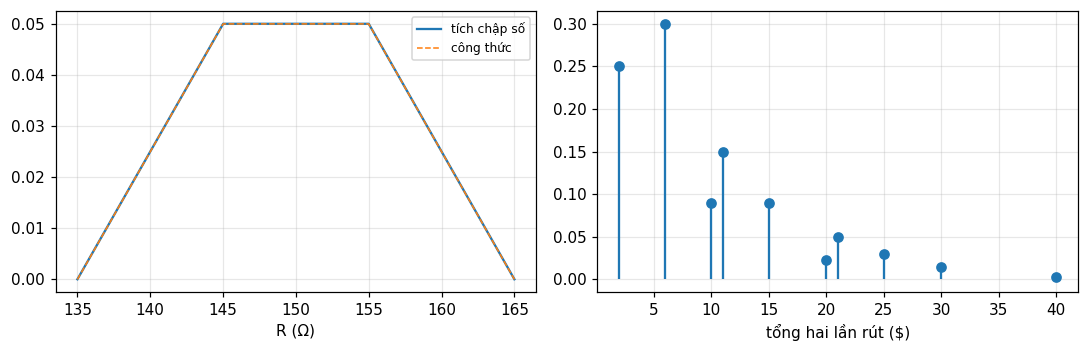

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))
ax[0].plot(Rt, conv, label=("tích chập số")); ax[0].plot(Rt, analytic(Rt), "--", lw=1, label=("công thức"))
ax[0].set_xlabel("R (Ω)"); ax[0].legend(fontsize=8)
ks_ = sorted(p2); ax[1].stem(ks_, [float(p2[k]) for k in ks_], basefmt=" "); ax[1].set_xlabel(("tổng hai lần rút ($)"))
plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Điện trở: trung bình 150, độ lệch chuẩn 6.455 (4.3 phần trăm so với 5.77), mật độ tại 140 là 0.025. Chai tiền: 0.3, 0.15, tổng 1, trung bình 9, phương sai 45.5; phụ thuộc: 0. Tổng đều: 0.25, 0.5, 0.25. Tích $f_U(0.2)$ = 1.6094, $E[U]$ = 0.25; $E[M]$ = 0.6667, $E[N]$ = 0.3333; $Y=2X^2$: $E$ = 2, $P(Y\le1)$ = 0.5205.

## 4. Hàm đặc trưng, giới hạn trung tâm, các cận
🎯 **Phương pháp này trả lời câu hỏi gì?** Hàm đặc trưng có cho mômen và tổng độc lập đúng, mật độ tổng 12 biến đều có gần Gauss, và Tchebycheff, Chernoff, luật số lớn cho cận ra sao so với giá trị thật?

In [6]:
# Laplace: φ(t) = 1/(1+t²)
lap = lambda x: 0.5*np.exp(-abs(x))
phi_num = integrate.quad(lambda x: lap(x)*np.cos(0.5*x), -80, 80, points=[0], limit=800)[0]
assert abs(phi_num - 1/(1 + 0.25)) < 1e-8
report("cf_lap", phi_num, ".4f")
# liên hệ Bracewell φ(t) = F(−t/2π), F(s) = ∫P e^{−i2πxs}
t7 = 0.7; s7 = -t7/(2*np.pi)
F7 = integrate.quad(lambda x: lap(x)*np.cos(2*np.pi*x*s7), -80, 80, points=[0], limit=800)[0]
assert abs(F7 - 1/(1 + t7**2)) < 1e-8
report("cf_rel", F7, ".4f")
# mômen từ đạo hàm (tích phân đường qua FFT)
def derivs(fun, nmax, r=0.3, N=128):
    th = 2*np.pi*np.arange(N)/N
    coef = np.fft.fft(fun(r*np.exp(1j*th)))/N
    return [coef[n]*factorial(n)/r**n for n in range(nmax + 1)]
dv = derivs(lambda t: 1/(1 + t**2), 4)
m2_cf = (-(1j)**2*dv[2]).real*(-1)**0        # E[X^n] = (−i)^n φ^(n)(0)
m2_cf = ((-1j)**2*dv[2]).real; m4_cf = ((-1j)**4*dv[4]).real
m2_q = integrate.quad(lambda x: x**2*lap(x), -80, 80, points=[0], limit=800)[0]
m4_q = integrate.quad(lambda x: x**4*lap(x), -120, 120, points=[0], limit=800)[0]
assert abs(m2_cf - 2) < 1e-8 and abs(m4_cf - 24) < 1e-6 and abs(m2_q - 2) < 1e-6 and abs(m4_q - 24) < 1e-4
report("cf_m2", m2_cf, ".0f"); report("cf_m4", m4_cf, ".0f")
# tổng hai Laplace: f(0)
f0_a = integrate.quad(lambda t: (1/(1 + t*t))**2, -np.inf, np.inf)[0]/(2*np.pi)
f0_b = integrate.quad(lambda u: lap(u)*lap(-u), -60, 60, points=[0], limit=400)[0]
assert abs(f0_a - 0.25) < 1e-9 and abs(f0_b - 0.25) < 1e-9
report("cf_sum0", f0_a, ".2f")
# tính chất: mũ đơn vị
tg = np.linspace(-50, 50, 200001)
ph_e = 1/(1 - 1j*tg)
herm = np.max(np.abs(ph_e[::-1] - np.conj(ph_e)))
assert abs(1/(1 - 0j) - 1) < 1e-15 and np.max(np.abs(ph_e)) <= 1 + 1e-12 and herm < 1e-12
report("cf_0", 1.0, ".0f"); report("cf_max", np.max(np.abs(ph_e)), ".0f"); report("cf_herm", max(herm, 1e-16), ".0e")

# giới hạn trung tâm: 12 biến đều (−½, ½), phương sai 1
du = 0.005; base = np.ones(int(1/du))/1.0
cur = base.copy()
for _ in range(11): cur = np.convolve(cur, base)*du
xx = (np.arange(len(cur)) - (len(cur) - 1)/2)*du
f0_grid = cur[len(cur)//2]
f0_cf = integrate.quad(lambda t: np.sinc(t/(2*np.pi))**12, -60, 60, limit=800)[0]/(2*np.pi)
assert abs(f0_grid - f0_cf) < 2e-3 and abs(f0_cf - 1/np.sqrt(2*np.pi)) < 1e-2
report("clt_f0", f0_cf, ".4f"); report("clt_g0", 1/np.sqrt(2*np.pi), ".4f")

# Tchebycheff và Chernoff cho mũ đơn vị
true_ = lambda e: np.exp(-e)
cheb = lambda e: 1/(e - 1)**2           # P(X ≥ e) ⊂ P(|X−1| ≥ e−1)
def chern(e):
    r = optimize.minimize_scalar(lambda t: np.exp(-t*e)/(1 - t), bounds=(1e-6, 1 - 1e-6), method="bounded", options={"xatol": 1e-12})
    return r.fun
assert abs(chern(3) - 3*np.exp(-2)) < 1e-6 and abs(chern(10) - np.exp(-9)/0.1) < 1e-6
assert true_(3) < cheb(3) < chern(3) and true_(10) < chern(10) < cheb(10)
report("true_3", true_(3), ".4f"); report("cheb_3", cheb(3), ".4f"); report("chern_3", chern(3), ".4f")
report("true_10", true_(10), ".1e"); report("cheb_10", cheb(10), ".4f"); report("chern_10", chern(10), ".4f")

# luật số lớn: n = 1000, p = 0.3
n_, p_ = 1000, 0.3
k = np.arange(n_ + 1); pm = stats.binom.pmf(k, n_, p_)
ex = pm[np.abs(k/n_ - p_) >= 0.05 - 1e-12].sum()
ex2 = stats.binom.cdf(250, n_, p_) + stats.binom.sf(349, n_, p_)
bound = p_*(1 - p_)/(n_*0.05**2)
assert abs(ex - ex2) < 1e-12 and ex < bound
report("lln_exact", ex, ".4f"); report("lln_bound", bound, ".4f")

# điện trở chính xác
n = 10000; trials = 400
sigma = 0.01/np.sqrt(3)
ind_sd = sigma/np.sqrt(n)
sums_ind = (1 + rg.uniform(-0.01, 0.01, (trials, n))).mean(axis=1)
com = rg.uniform(-0.005, 0.005, trials)
sums_corr = (1 + com[:, None] + rg.uniform(-0.01, 0.01, (trials, n))).mean(axis=1)
corr_sd = np.sqrt((0.005/np.sqrt(3))**2 + ind_sd**2)
assert abs(np.std(sums_ind)/ind_sd - 1) < 0.15 and abs(np.std(sums_corr)/corr_sd - 1) < 0.15
report("bo_ind", ind_sd, ".1e"); report("bo_corr", corr_sd, ".1e")

▸ cf_lap = 0.8
▸ cf_rel = 0.6711
▸ cf_m2 = 2
▸ cf_m4 = 24
▸ cf_sum0 = 0.25
▸ cf_0 = 1
▸ cf_max = 1
▸ cf_herm = 7e-15
▸ clt_f0 = 0.3939
▸ clt_g0 = 0.3989
▸ true_3 = 0.0498
▸ cheb_3 = 0.25
▸ chern_3 = 0.406
▸ true_10 = 4.5e-05
▸ cheb_10 = 0.0123
▸ chern_10 = 0.0012
▸ lln_exact = 0.0006
▸ lln_bound = 0.084
▸ bo_ind = 5.8e-05
▸ bo_corr = 2.9e-03


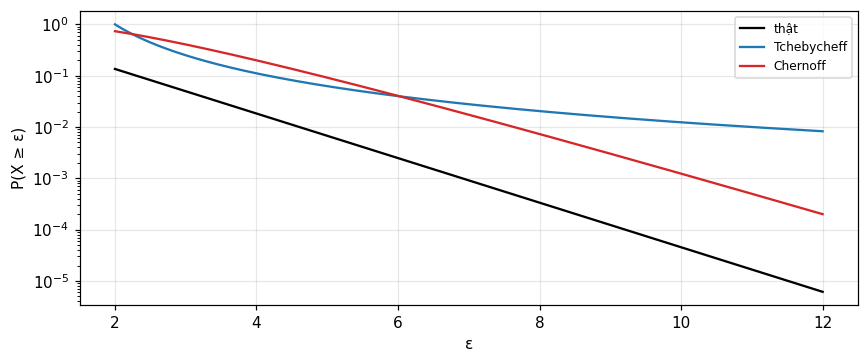

In [7]:
es = np.linspace(2, 12, 200)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.semilogy(es, [true_(e) for e in es], "k", label=("thật"))
ax.semilogy(es, [cheb(e) for e in es], "tab:blue", label=("Tchebycheff"))
ax.semilogy(es, [chern(e) for e in es], "tab:red", label="Chernoff")
ax.set_xlabel("ε"); ax.set_ylabel("P(X ≥ ε)"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Laplace: $\phi(0.5)$ = 0.8, $\phi(0.7)$ theo Bracewell 0.6711, $E[X^2]$ = 2, $E[X^4]$ = 24, mật độ tổng tại 0 0.25. Mũ đơn vị: $\phi(0)$ = 1, $\max|\phi|$ = 1, lệch Hermite 7e-15. Tổng 12 biến đều: 0.3939 so với 0.3989. Cận: $P(X\ge3)$ thật 0.0498, Tchebycheff 0.25, Chernoff 0.406; $P(X\ge10)$ thật 4.5e-05, 0.0123, 0.0012. Luật số lớn: chính xác 0.0006, cận 0.084. Điện trở chính xác: 5.8e-05 và 2.9e-03.

## 5. Mũ, gamma, Poisson và hai chiều
🎯 **Phương pháp này trả lời câu hỏi gì?** Khoảng giữa các biến cố ngẫu nhiên có phân bố mũ, tự tích chập cho gamma, đếm cho Poisson, Poisson cộng, nhị thức gần Gauss? Và các ví dụ hai chiều (1.15 đến 1.18) đúng ra sao?

In [8]:
# giới hạn (1 − Δx/X)^N / X
Xm, x0 = 2.0, 3.0
Nlim = 10**7
lim_val = (1 - (x0/Nlim)/Xm)**Nlim/Xm
assert abs(lim_val - np.exp(-x0/Xm)/Xm) < 1e-6
report("ex_pdf", lim_val, ".4f")
# mô phỏng: khoảng giữa các biến cố của quá trình Poisson với tốc độ 1/X
arr = np.cumsum(rg.exponential(Xm, 1000000)); iv = np.diff(arr)
qm = integrate.quad(lambda x: x*np.exp(-x/Xm)/Xm, 0, np.inf)[0]; qv = integrate.quad(lambda x: x*x*np.exp(-x/Xm)/Xm, 0, np.inf)[0] - qm**2
assert abs(np.mean(iv) - qm) < 0.01 and abs(np.var(iv) - qv) < 0.05 and abs(qm - 2) < 1e-9 and abs(qv - 4) < 1e-9
report("ex_mean", np.mean(iv), ".2f"); report("ex_var", np.var(iv), ".1f")

# gamma: E*E, [E]^{*5}
from scipy.signal import fftconvolve
dxg = 0.002; xg = np.arange(0, 40, dxg); E1 = np.exp(-xg)
cur = E1.copy(); conv_pows = {1: E1.copy()}
for n_ in range(2, 6):
    cur = fftconvolve(cur, E1)[:len(xg)]*dxg
    conv_pows[n_] = cur.copy()
g2 = conv_pows[2][int(round(2/dxg))]; g5 = conv_pows[5][int(round(4/dxg))]
assert abs(g2 - 2*np.exp(-2)) < 2e-3 and abs(g5 - 4**4*np.exp(-4)/24) < 2e-3
assert abs(g5 - stats.gamma.pdf(4, a=5)) < 2e-3
ar5 = trap(conv_pows[5], xg); mean5 = trap(xg*conv_pows[5], xg)/ar5; var5 = trap(xg**2*conv_pows[5], xg)/ar5 - mean5**2
assert abs(mean5 - 5) < 5e-2 and abs(var5 - 5) < 0.1
report("gam2", 2*np.exp(-2), ".4f"); report("gam5", 4**4*np.exp(-4)/24, ".4f"); report("gam_mean", 5, "d"); report("gam_var", 5, "d")
# Stirling, n = 100
nS = 100
gam = stats.gamma.pdf(nS, a=nS); gauss = 1/np.sqrt(2*np.pi*nS)
gam_log = np.exp((nS - 1)*np.log(nS) - nS - special.gammaln(nS))
assert abs(gam - gam_log) < 1e-12
report("st_ratio", gam/gauss, ".4f")

# Poisson từ khoảng
xn, nn = 3.0, 2
po_int = integrate.quad(lambda xp: xp**(nn - 1)/factorial(nn - 1)*np.exp(-xp)*np.exp(-(xn - xp)), 0, xn)[0]
po_form = xn**nn/factorial(nn)*np.exp(-xn)
assert abs(po_int - po_form) < 1e-10 and abs(po_int - stats.poisson.pmf(nn, xn)) < 1e-12
cnts = np.searchsorted(arr, 3.0*Xm*0 + 0)*0        # (giữ chỗ)
tr = np.cumsum(rg.exponential(1.0, (200000, 12)), axis=1)
mc = np.mean((tr < 3.0).sum(axis=1) == 2)
assert abs(mc - po_form) < 3e-3
report("po_pmf", po_form, ".4f")
p5 = stats.poisson.pmf(2, 0.1); assert abs(p5 - np.exp(-0.1)*0.01/2) < 1e-15
report("p5_val", p5, ".4f")
ks5 = np.arange(0, 60)
po_sum = stats.poisson.pmf(ks5, 4).sum(); assert abs(po_sum - 1) < 1e-12 and abs(stats.poisson.pmf(3, 4) - stats.poisson.pmf(4, 4)) < 1e-15
report("po_sum", po_sum, ".0f"); report("po_eq", stats.poisson.pmf(4, 4), ".4f")
pa2 = stats.poisson.pmf(np.arange(0, 40), 2); pb3 = stats.poisson.pmf(np.arange(0, 40), 3)
conv_po = np.convolve(pa2, pb3)[5]
assert abs(conv_po - stats.poisson.pmf(5, 5)) < 1e-12
report("po_add", conv_po, ".4f")
bn = np.array([1.0]);
for _ in range(20): bn = np.convolve(bn, [0.5, 0.5])
assert abs(bn[10] - comb(20, 10)/2**20) < 1e-15
report("bin_10", bn[10], ".4f"); report("bin_g", 1/np.sqrt(2*np.pi*20*0.25), ".4f")

# hai chiều: ví dụ 1.15
fxy = lambda y, x: x*x + x*y/3
J = integrate.dblquad(fxy, 0, 1, 0, 2)[0]
PX = integrate.quad(lambda x: integrate.quad(lambda y: fxy(y, x), 0, 2)[0], 0.5, 1)[0]
PYX = integrate.dblquad(fxy, 0, 1, 0, lambda x: x)[0]
PC = integrate.dblquad(fxy, 0, 0.5, 0, 0.5)[0]/integrate.dblquad(fxy, 0, 0.5, 0, 2)[0]
assert abs(J - 1) < 1e-9 and abs(PX - 5/6) < 1e-9 and abs(PYX - 7/24) < 1e-9 and abs(PC - 5/32) < 1e-9
xs_ = rg.random(2000000); ys_ = rg.random(2000000)*2                       # mô phỏng loại bỏ: mật độ ≤ 1 + 2/3
acc = rg.random(2000000)*(5/3) < xs_**2 + xs_*ys_/3
X_, Y_ = xs_[acc], ys_[acc]
assert abs(np.mean(X_ > 0.5) - 5/6) < 4e-3 and abs(np.mean(Y_ < X_) - 7/24) < 4e-3
report("j_int", J, ".1f"); report("j_px", PX, ".4f"); report("j_pyx", PYX, ".4f"); report("j_cond", PC, ".4f")
# bảng ví dụ 1.16
tabl = {(1, 0): Fr(1, 4), (2, 0): Fr(1, 4), (1, 1): Fr(0), (2, 1): Fr(1, 8), (1, 2): Fr(1, 4), (2, 2): Fr(1, 8)}
assert sum(tabl.values()) == 1
PX1 = sum(v for (x, y), v in tabl.items() if x == 1); PY2 = sum(v for (x, y), v in tabl.items() if y == 2)
assert PX1 == Fr(1, 2) and PY2 == Fr(3, 8) and tabl[(1, 2)] != PX1*PY2
report("j_dep", float(tabl[(1, 2)]), ".2f"); report("j_ind", float(PX1*PY2), ".4f")
# ví dụ 1.17
kk = 1/integrate.dblquad(lambda x, y: y*x, 0, 1, 0, lambda y: y)[0]
assert abs(kk - 8) < 1e-9
fYc = lambda y: 4*y**3
Exy = lambda y: integrate.quad(lambda x: x*8*x*y/fYc(y), 0, y)[0]
assert abs(Exy(0.6) - 0.4) < 1e-9
EX_tower = integrate.quad(lambda y: Exy(y)*fYc(y), 0, 1)[0]
EX_dir = integrate.dblquad(lambda x, y: x*8*x*y, 0, 1, 0, lambda y: y)[0]
assert abs(EX_tower - 8/15) < 1e-9 and abs(EX_dir - 8/15) < 1e-9
report("c17_k", kk, ".0f"); report("c17_e", Exy(0.6), ".2f"); report("c17_ex", EX_dir, ".4f")
# nửa đĩa
hd = lambda y, x: 2/np.pi
EYh = integrate.dblquad(lambda x, y: y*2/np.pi, 0, 1, lambda y: -np.sqrt(1 - y*y), lambda y: np.sqrt(1 - y*y))[0]
EXYh = integrate.dblquad(lambda x, y: x*y*2/np.pi, 0, 1, lambda y: -np.sqrt(1 - y*y), lambda y: np.sqrt(1 - y*y))[0]
assert abs(EYh - 4/(3*np.pi)) < 1e-9 and abs(EXYh) < 1e-9
pj = integrate.dblquad(lambda y, x: 2/np.pi, 0.7, 1, 0.8, lambda x: np.sqrt(max(1 - x*x, 0)))[0] if False else 0.0
# P(X > 0.7, Y > 0.8) = 0 vì 0.7² + 0.8² = 1.13 > 1
assert 0.7**2 + 0.8**2 > 1
px7 = integrate.dblquad(lambda y, x: 2/np.pi, 0.7, 1, 0, lambda x: np.sqrt(1 - x*x))[0]
py8 = integrate.dblquad(lambda x, y: 2/np.pi, 0.8, 1, lambda y: -np.sqrt(1 - y*y), lambda y: np.sqrt(1 - y*y))[0]
assert px7*py8 > 0
ang = rg.random(2000000)*np.pi; rad = np.sqrt(rg.random(2000000))
Xh, Yh = rad*np.cos(ang), rad*np.sin(ang)
assert abs(np.mean((Xh > 0.7) & (Yh > 0.8))) < 1e-9 and abs(np.mean(Yh) - EYh) < 2e-3 and abs(np.corrcoef(Xh, Yh)[0, 1]) < 3e-3
report("hd_ey", EYh, ".4f"); report("hd_pj", 0.0, ".4f"); report("hd_pp", px7*py8, ".4f")

▸ ex_pdf = 0.1116
▸ ex_mean = 2
▸ ex_var = 4


▸ gam2 = 0.2707
▸ gam5 = 0.1954
▸ gam_mean = 5
▸ gam_var = 5
▸ st_ratio = 0.9992
▸ po_pmf = 0.224
▸ p5_val = 0.0045
▸ po_sum = 1
▸ po_eq = 0.1954
▸ po_add = 0.1755
▸ bin_10 = 0.1762
▸ bin_g = 0.1784
▸ j_int = 1
▸ j_px = 0.8333
▸ j_pyx = 0.2917
▸ j_cond = 0.1562
▸ j_dep = 0.25
▸ j_ind = 0.1875
▸ c17_k = 8
▸ c17_e = 0.4
▸ c17_ex = 0.5333
▸ hd_ey = 0.4244
▸ hd_pj = 0
▸ hd_pp = 0.0098


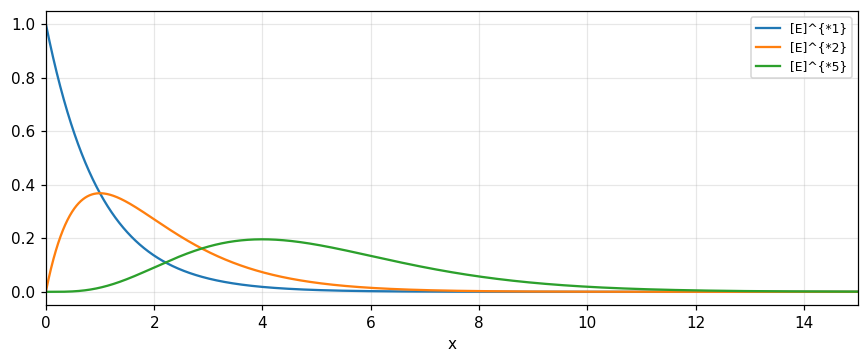

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.4))
for n_, c in ((1, "tab:blue"), (2, "tab:orange"), (5, "tab:green")):
    ax.plot(xg, conv_pows[n_], color=c, label=f"[E]^{{*{n_}}}")
ax.set_xlim(0, 15); ax.set_xlabel("x"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Mũ $X=2$: mật độ giới hạn tại 3 là 0.1116, trung bình 2, phương sai 4. Gamma: 0.2707 và 0.1954, trung bình và phương sai 5; Stirling tại 100 cho tỉ số 0.9992. Poisson: 0.224, 0.0045, tổng 1, $P(3)=P(4)$ = 0.1954, cộng 0.1755; nhị thức 0.1762 so với 0.1784. Ví dụ 1.15: 1, 0.8333, 0.2917, 0.1562. Ví dụ 1.16: 0.25 và 0.1875. Ví dụ 1.17: $k$ = 8, 0.4, 0.5333. Nửa đĩa: $E[Y]$ = 0.4244; 0 so với 0.0098.